In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tatianasnwrt/russian-handwritten-letters")

print("Path to dataset files:", path)

100%|██████████| 110M/110M [00:06<00:00, 16.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18


In [4]:
import os
i=0
for root,dir,files in os.walk(path):
  i +=1
  print(f"--------------------------------------------------------{i}th itration--------------------------------------------------------")
  j=0
  for file in files:
     j +=1
     print(os.path.join(root,file))
     print(j)


--------------------------------------------------------1th itration--------------------------------------------------------
/root/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18/all_letters_info.csv
1
--------------------------------------------------------2th itration--------------------------------------------------------
--------------------------------------------------------3th itration--------------------------------------------------------
/root/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18/all_letters_image/all_letters_image/17_317.png
1
/root/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18/all_letters_image/all_letters_image/09_427.png
2
/root/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18/all_letters_image/all_letters_image/14_231.png
3
/root/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18/all_letters_image/all_letters_

In [5]:
import pandas as pd
data=pd.read_csv("/root/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18/all_letters_info.csv")
data.tail(10)

data["label"].unique()


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])

In [6]:
from sklearn.model_selection import train_test_split
import torch

data_train,data_test=train_test_split(data,test_size=0.2,random_state=42)
label=data_train["label"][30]
label=torch.tensor(label,dtype=torch.long)



In [7]:
# this is for testing

import os
from PIL import Image
import matplotlib.pyplot as plt

dir="/root/.cache/kagglehub/datasets/tatianasnwrt/russian-handwritten-letters/versions/18/all_letters_image/all_letters_image"

# file=data["file"][80]

# path =os.path.join(dir,file)
# print(path)

# image=Image.open(path)

# plt.imshow(image)

# print("size:",image.size,"mode",image.mode)




In [8]:
from torch.utils.data import Dataset,DataLoader

class Dataset(Dataset):
  def __init__(self,x,dir,transform=None):
    self.x=x
    self.transform=transform
    self.dir=dir
  def __len__(self):
    return len(self.x)

  def __getitem__(self,index):
    file=self.x.iloc[index]["file"]
    path=os.path.join(self.dir,file)
    image=Image.open(path).convert("RGB")

    if self.transform:
      image=self.transform(image)
    label=self.x.iloc[index]["label"]
    label=torch.tensor(label-1,dtype=torch.long) # label = label-1 because the cnn goes to 0 to 32 but this label goes 1 to 33

    return image,label

from torchvision import transforms

transform=transforms.Compose(
  [  transforms.ToTensor(),
    transforms.Resize((32,32)),
    transforms.RandomHorizontalFlip()]

    )

train_data=Dataset(data_train,dir,transform=transform)
test_data=Dataset(data_test,dir,transform=transform)






In [9]:
train_loader=DataLoader(train_data,batch_size=25,shuffle=True)
test_loader=DataLoader(test_data,batch_size=25,shuffle=False)

In [10]:
for images,label in train_loader:
  for image in images:
    print(image.shape,label.shape)

  break

torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 32, 32]) torch.Size([25])
torch.Size([3, 3

In [36]:
import torch.nn as nn


print(nn.Flatten(image))

class Model(nn.Module):
  def __init__(self):
    super().__init__()

    self.feature=nn.Sequential(
        nn.Conv2d(in_channels=3,out_channels=25,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Conv2d(in_channels=25,out_channels=36,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
          )
    self.linear=nn.Sequential(
        nn.Flatten(),
        nn.Linear(36*8*8,450),
        nn.ReLU(),
        nn.Linear(450,200),
        nn.ReLU(),
        nn.Linear(200,33)
                )
  def forward(self,x):
    x=self.feature(x)
    x=self.linear(x)
    return x

model=Model()

Flatten(start_dim=[25, 36, 8, 8], end_dim=-1)


In [37]:
for params in model.parameters():
  print(params.shape)


torch.Size([25, 3, 3, 3])
torch.Size([25])
torch.Size([36, 25, 3, 3])
torch.Size([36])
torch.Size([450, 2304])
torch.Size([450])
torch.Size([200, 450])
torch.Size([200])
torch.Size([33, 200])
torch.Size([33])


In [38]:
# for speed up
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model=model.to(device)

cuda


In [40]:
# i want to predict for 1 batch so

for images, labels in train_loader:
  print(images.shape)
  images=images.to(device)
  labels=labels.to(device)

  output=model(images)
#   output=model(images)

  print("input shape",images.shape)
  print("output shape",output.shape)
  print("label.shape",labels.shape)
  break



torch.Size([25, 3, 32, 32])
input shape torch.Size([25, 3, 32, 32])
output shape torch.Size([25, 33])
label.shape torch.Size([25])


In [41]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)
criterian=nn.CrossEntropyLoss()

In [52]:
loss_1=[]
for i in range(30):
    total_loss=0
    for image,label in train_loader:
      image=image.to(device)
      label=label.to(device)
      optimizer.zero_grad()
      y_pred=model(image)
      loss=criterian(y_pred,label)

      loss.backward()
      optimizer.step()

      total_loss += loss.item()
    avg_loss=total_loss/len(train_loader)
    loss_1.append(avg_loss)
    print("epoch",i,"aveg Loss",total_loss/len(train_loader))





epoch 0 aveg Loss 0.30598530122929685
epoch 1 aveg Loss 0.289935988171415
epoch 2 aveg Loss 0.2815089967745295
epoch 3 aveg Loss 0.30678625478828836
epoch 4 aveg Loss 0.26497102552656454
epoch 5 aveg Loss 0.2383399147867829
epoch 6 aveg Loss 0.35704328019867887
epoch 7 aveg Loss 0.218359019779242
epoch 8 aveg Loss 0.23533975494268175
epoch 9 aveg Loss 0.1999023755111701
epoch 10 aveg Loss 0.23719907726601258
epoch 11 aveg Loss 0.2144763536219086
epoch 12 aveg Loss 0.23890061957311615
epoch 13 aveg Loss 0.18943164565774437
epoch 14 aveg Loss 0.22331291370216635
epoch 15 aveg Loss 0.21198968173383356
epoch 16 aveg Loss 0.2028146078125836
epoch 17 aveg Loss 0.20748349097813223
epoch 18 aveg Loss 0.2145637367944141
epoch 19 aveg Loss 0.19649157552457935
epoch 20 aveg Loss 0.17091733019563604
epoch 21 aveg Loss 0.21325361304353205
epoch 22 aveg Loss 0.17558612938878218
epoch 23 aveg Loss 0.18886804576799437
epoch 24 aveg Loss 0.14255002223896784
epoch 25 aveg Loss 0.14868801722988073
epoch 

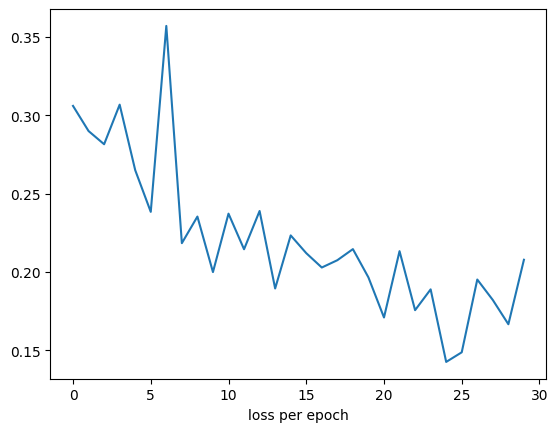

In [53]:

import matplotlib.pyplot as plt

plt.plot(loss_1,label="cisualization of loss per epoch")

plt.xlabel("epoch")
plt.xlabel("loss per epoch")


plt.show()


In [54]:
model.eval()

Model(
  (feature): Sequential(
    (0): Conv2d(3, 25, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(25, 36, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2304, out_features=450, bias=True)
    (2): ReLU()
    (3): Linear(in_features=450, out_features=200, bias=True)
    (4): ReLU()
    (5): Linear(in_features=200, out_features=33, bias=True)
  )
)

In [55]:
correct=0
total=0
with torch.no_grad():
    for  image,label in test_loader:
      image = image.to(device)
      label = label.to(device)


      output=model(image)

      prediction=torch.argmax(output,dim=1)

      total += label.size(0)

      correct += (prediction==label).sum().item()
    accuracy = (correct/total)*100

    print("accuracy:",accuracy,"%")


accuracy: 69.59126145172657 %
